# Output Rendering Test Suite
More than 25 cells covering every output channel the notebook UI understands: **stdout**, **return values**, **errors/tracebacks**, **images/graphs**, **HTML**, **SVG**, **JSON**, and **widgets**, plus general robustness checks (unicode, large output, nested structures, warnings, long-running cells).

Run every cell top to bottom and confirm each one renders the output type its section heading promises.

## 1. Plain stdout

In [ ]:
print("Hello from stdout - Test 1")

Hello from stdout - Test 1


In [ ]:
for i in range(5):
    print(f"stdout line {i}", end=" | ")
print()
print("multi-line stdout block", "second arg", sep=" :: ")

stdout line 0 | stdout line 1 | stdout line 2 | stdout line 3 | stdout line 4 | 
multi-line stdout block :: second arg


## 2. Return-value (result) rendering

In [91]:
2 + 2

4

In [92]:
[1, 2, 3, 4, 5]

[1, 2, 3, 4, 5]

In [93]:
{"a": 1, "b": 2, "c": [1, 2, 3], "d": {"nested": True}}

{'a': 1, 'b': 2, 'c': [1, 2, 3], 'd': {'nested': True}}

In [94]:
import numpy as np
arr = np.arange(12).reshape(3, 4)
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 3. Errors and tracebacks

In [95]:
raise ValueError("Intentional test error - a traceback should render below this cell")

Error: 

In [96]:
1 / 0  # ZeroDivisionError test

Error: 

In [ ]:
try:
    int("not-a-number")
except ValueError as e:
    print("Caught expected error:", e)
    print("PASS: exception handling inside a cell works")

Caught expected error: invalid literal for int() with base 10: 'not-a-number'
PASS: exception handling inside a cell works


## 4. Images and graphs (matplotlib)

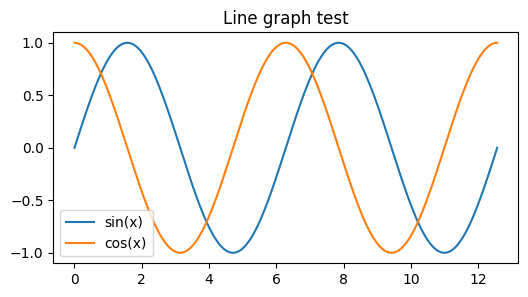

In [98]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 4 * np.pi, 200)
plt.figure(figsize=(6, 3))
plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, np.cos(x), label="cos(x)")
plt.title("Line graph test")
plt.legend()
plt.show()

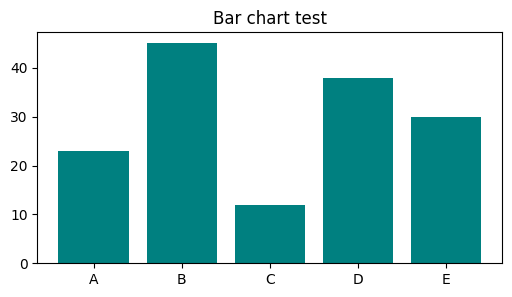

In [ ]:
categories = ["A", "B", "C", "D", "E"]
values = [23, 45, 12, 38, 30]
plt.figure(figsize=(6, 3))
plt.bar(categories, values, color="teal")
plt.title("Bar chart test")
plt.show()

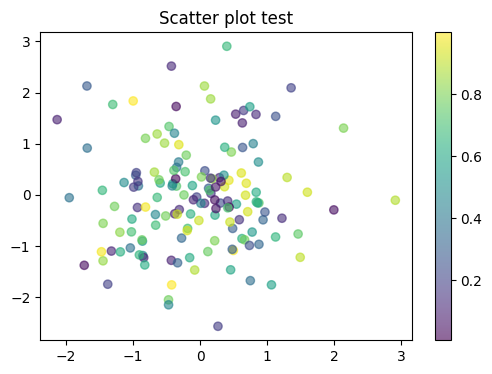

In [ ]:
rng = np.random.default_rng(42)
plt.figure(figsize=(6, 4))
plt.scatter(rng.normal(size=150), rng.normal(size=150), alpha=0.6, c=rng.random(150), cmap="viridis")
plt.title("Scatter plot test")
plt.colorbar()
plt.show()

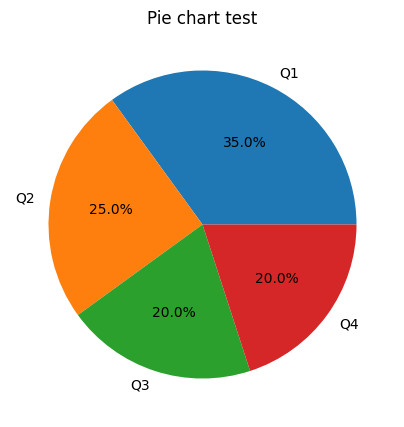

In [ ]:
plt.figure(figsize=(5, 5))
plt.pie([35, 25, 20, 20], labels=["Q1", "Q2", "Q3", "Q4"], autopct="%1.1f%%")
plt.title("Pie chart test")
plt.show()

In [ ]:
plt.figure(figsize=(6, 3))
plt.hist(rng.normal(size=1000), bins=30, color="orange", edgecolor="black")
plt.title("Histogram test")
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes[0, 0].plot(x, np.sin(x)); axes[0, 0].set_title("sin")
axes[0, 1].bar(categories, values); axes[0, 1].set_title("bar")
axes[1, 0].scatter(rng.normal(size=80), rng.normal(size=80)); axes[1, 0].set_title("scatter")
axes[1, 1].hist(rng.normal(size=500), bins=20); axes[1, 1].set_title("hist")
fig.suptitle("Subplot grid test (4 chart types in one figure)")
fig.tight_layout()
plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
xs = rng.normal(size=60)
ys = rng.normal(size=60)
zs = rng.normal(size=60)
ax.scatter(xs, ys, zs, c=zs, cmap="plasma")
ax.set_title("3D scatter test")
plt.show()

## 5. HTML output

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "id": range(1, 6),
    "name": ["Alice", "Bob", "Carla", "Dev", "Eve"],
    "score": [91.5, 88.2, 76.0, 95.3, 60.1],
})
df  # bare DataFrame -> rendered as an HTML table

In [ ]:
from IPython.display import HTML

HTML(
    "<h3 style=\"color:teal\">Custom HTML block</h3>"
    "<p>This exercises the <b>html</b> output channel directly "
    "(not via a DataFrame).</p>"
    "<ul><li>item one</li><li>item two</li></ul>"
)

## 6. SVG output

In [ ]:
from IPython.display import SVG

svg_markup = (
    '<svg xmlns="http://www.w3.org/2000/svg" width="160" height="160">'
    '<circle cx="80" cy="80" r="70" fill="#4C9AFF" stroke="#0747A6" stroke-width="4" />'
    '<text x="80" y="85" font-size="16" text-anchor="middle" fill="white">SVG test</text>'
    '</svg>'
)
SVG(data=svg_markup)

In [ ]:
import io

fig2, ax2 = plt.subplots(figsize=(4, 3))
ax2.plot([0, 1, 2, 3], [0, 1, 4, 9], marker="o")
ax2.set_title("Matplotlib figure saved as SVG")
buf = io.StringIO()
fig2.savefig(buf, format="svg")
plt.close(fig2)
SVG(data=buf.getvalue())

## 7. JSON output

In [ ]:
from IPython.display import JSON

JSON({"status": "ok", "values": [1, 2, 3], "nested": {"flag": True, "empty": None}})

In [ ]:
import json

payload = {"user": "tester", "attempts": 3, "tags": ["a", "b", "c"], "score": 99.5}
print(json.dumps(payload, indent=2))

## 8. Widgets (best-effort - only renders if ipywidgets is installed)

In [ ]:
try:
    import ipywidgets as widgets
    display(widgets.IntSlider(value=25, min=0, max=100, description="Widget test:"))
except Exception as e:
    print("ipywidgets not available in this kernel - skipping widget test:", e)

## 9. Robustness / misc checks

In [ ]:
print("Unicode + emoji test: caf\u00e9, \u4e2d\u6587, \U0001F680\U0001F642\U0001F4CA")

In [ ]:
for i in range(60):
    print(f"long-output line {i:02d} " + "x" * 20)
print("PASS: large stdout block finished without truncation errors")

long-output line 00 xxxxxxxxxxxxxxxxxxxx
long-output line 01 xxxxxxxxxxxxxxxxxxxx
long-output line 02 xxxxxxxxxxxxxxxxxxxx
long-output line 03 xxxxxxxxxxxxxxxxxxxx
long-output line 04 xxxxxxxxxxxxxxxxxxxx
long-output line 05 xxxxxxxxxxxxxxxxxxxx
long-output line 06 xxxxxxxxxxxxxxxxxxxx
long-output line 07 xxxxxxxxxxxxxxxxxxxx
long-output line 08 xxxxxxxxxxxxxxxxxxxx
long-output line 09 xxxxxxxxxxxxxxxxxxxx
long-output line 10 xxxxxxxxxxxxxxxxxxxx
long-output line 11 xxxxxxxxxxxxxxxxxxxx
long-output line 12 xxxxxxxxxxxxxxxxxxxx
long-output line 13 xxxxxxxxxxxxxxxxxxxx
long-output line 14 xxxxxxxxxxxxxxxxxxxx
long-output line 15 xxxxxxxxxxxxxxxxxxxx
long-output line 16 xxxxxxxxxxxxxxxxxxxx
long-output line 17 xxxxxxxxxxxxxxxxxxxx
long-output line 18 xxxxxxxxxxxxxxxxxxxx
long-output line 19 xxxxxxxxxxxxxxxxxxxx
long-output line 20 xxxxxxxxxxxxxxxxxxxx
long-output line 21 xxxxxxxxxxxxxxxxxxxx
long-output line 22 xxxxxxxxxxxxxxxxxxxx
long-output line 23 xxxxxxxxxxxxxxxxxxxx
long-output line

In [13]:
(
    ("tuple", "of", "strings"),
    {"nested_dict": {"deep": {"deeper": [1, 2, {"deepest": True}]}}},
)

(('tuple', 'of', 'strings'),
 {'nested_dict': {'deep': {'deeper': [1, 2, {'deepest': True}]}}})

In [14]:
import warnings

warnings.warn("Intentional test warning - should not crash the cell")
print("PASS: warning raised without failing the cell")

PASS: warning raised without failing the cell
/tmp/ipykernel_364077/1821166233.py:3: UserWarning: Intentional test warning - should not crash the cell
  warnings.warn("Intentional test warning - should not crash the cell")


In [ ]:
import time

print("Sleeping for 2 seconds to test the running/spinner state...")
time.sleep(2)
print("done sleeping - PASS")

Sleeping for 2 seconds to test the running/spinner state...
done sleeping - PASS


## Done
If every cell above rendered its expected output type (stdout, result, error, image, html, svg, json[, widget]), the in-cell output pipeline is verified end to end.